In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [59]:
df = pd.read_csv("/content/heart (1).csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [60]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [63]:
cat_num = df.select_dtypes(include='number').columns
cat_num


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

<Axes: >

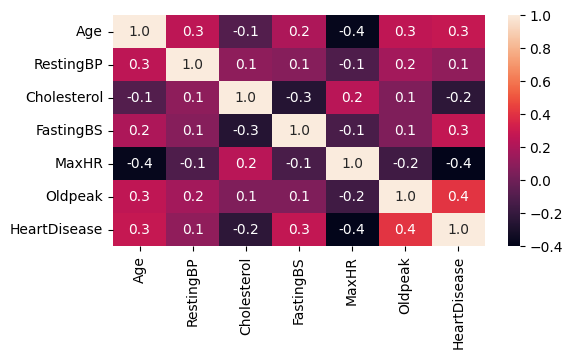

In [64]:
df1 = df.select_dtypes(include=['number'])
plt.figure(figsize=(6,3 ))
sns.heatmap(df1.corr(),annot=True,fmt=".1f")

In [65]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


In [66]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [67]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1,1
914,68,1,0,144,193,1,1,141,0,3.4,1,1
915,57,1,0,130,131,0,1,115,1,1.2,1,1
916,57,0,1,130,236,0,0,174,0,0.0,1,1


In [68]:
x = df.drop("HeartDisease", axis=1) # INDEPENDENT COLUMNS
x
y = df["HeartDisease"] #Dependent Columns
y

# standardize the features using StandardScalar
scaler = StandardScaler()
x=scaler.fit_transform(x)

x_train, x_test, y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)


In [69]:
DT =DecisionTreeClassifier()
DT.fit(x_train,y_train)

DecisionTreeClassifier()

In [70]:
y_pred_Dt = DT.predict(x_test)
accuracy = accuracy_score(y_test,y_pred_Dt)
conf = confusion_matrix(y_test ,y_pred_Dt)
clas =classification_report(y_test,y_pred_Dt)

print("accuracyscore_Dt",accuracy)
print("Confusionmat_Dt",conf)
print("classificationrep_Dt",clas)


accuracyscore_Dt 0.7989130434782609
Confusionmat_Dt [[64 13]
 [24 83]]
classificationrep_Dt               precision    recall  f1-score   support

           0       0.73      0.83      0.78        77
           1       0.86      0.78      0.82       107

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



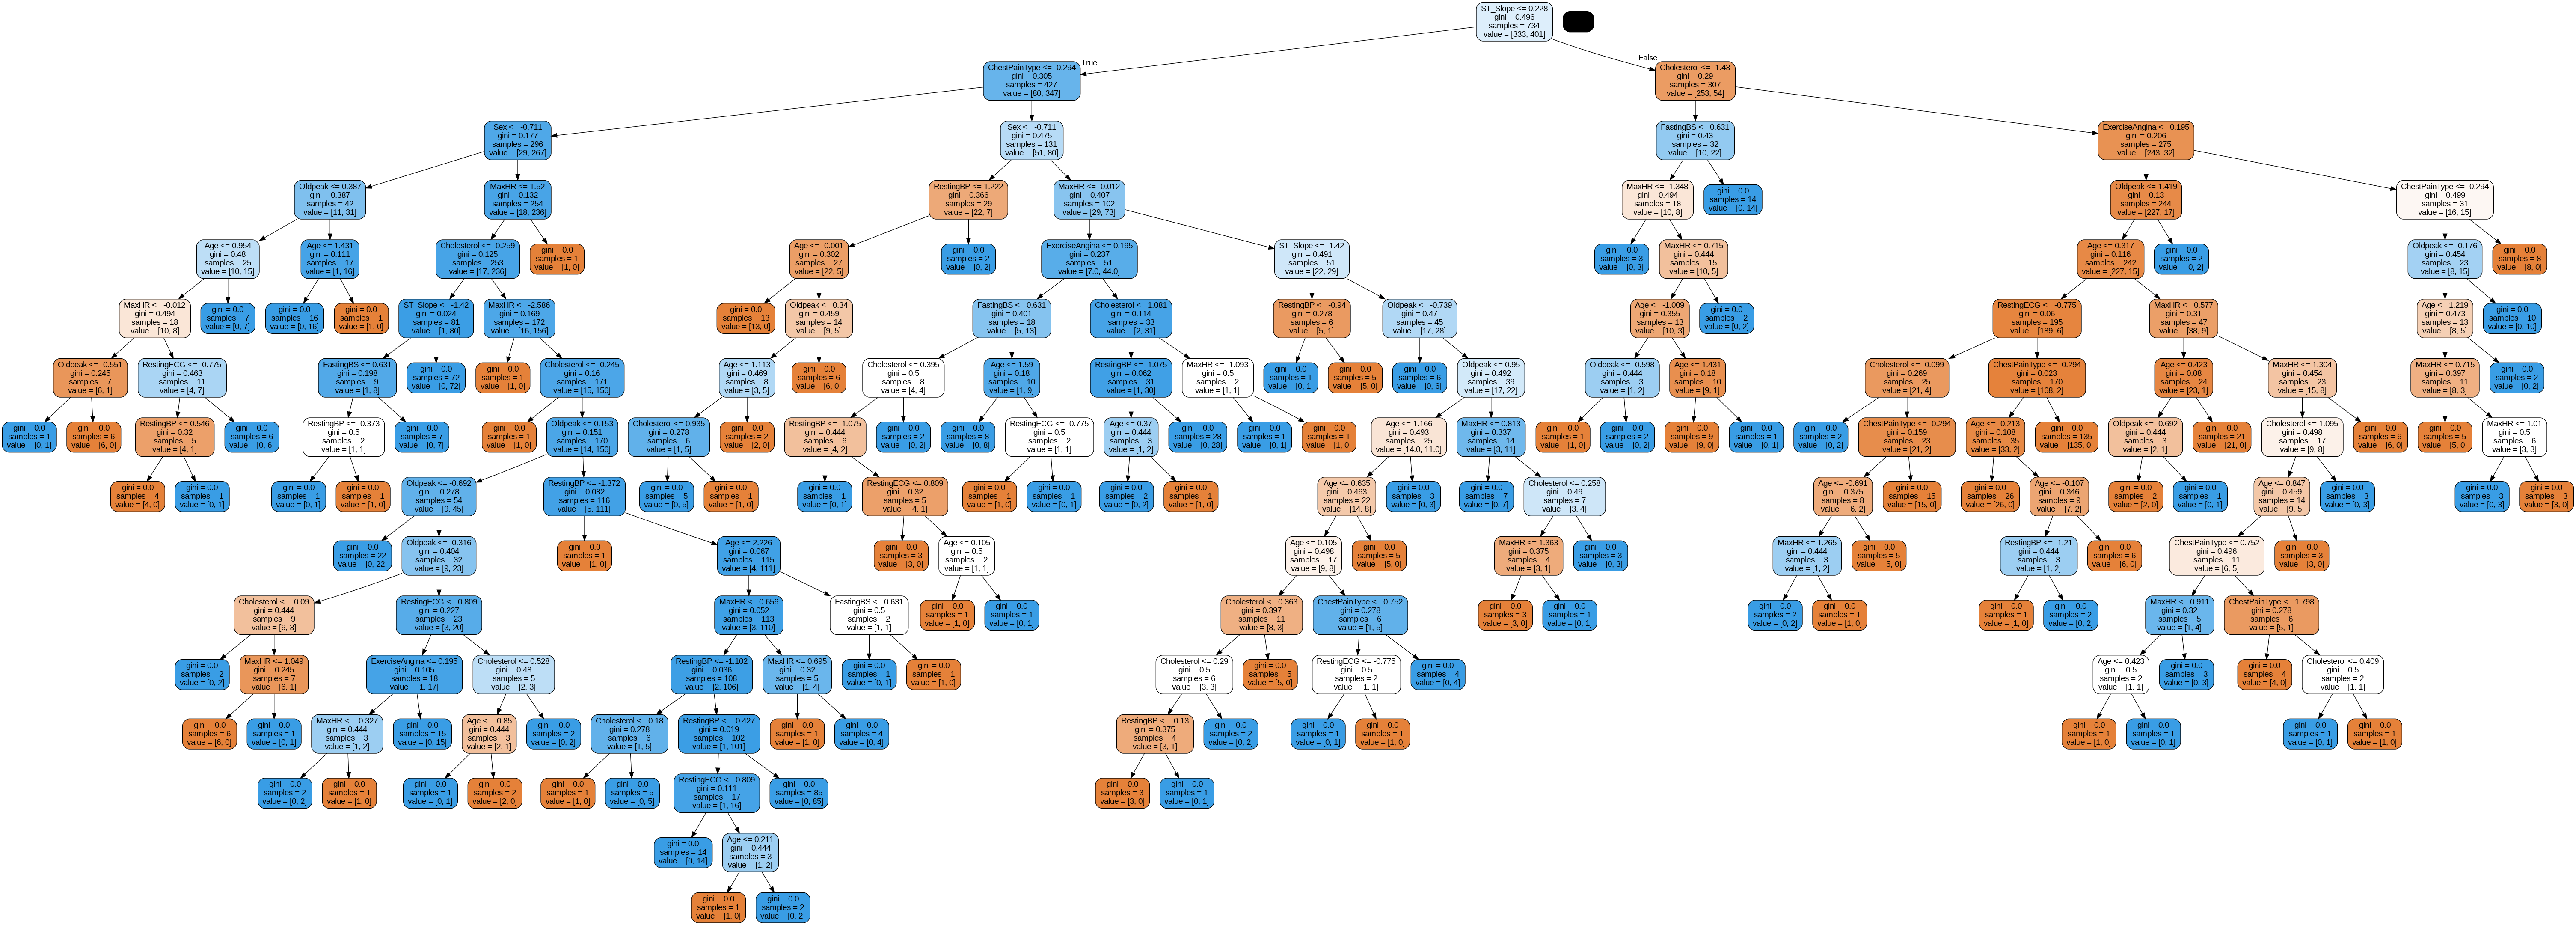

In [71]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

dot_data = export_graphviz(DT, feature_names=df.drop('HeartDisease', axis=1).columns, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

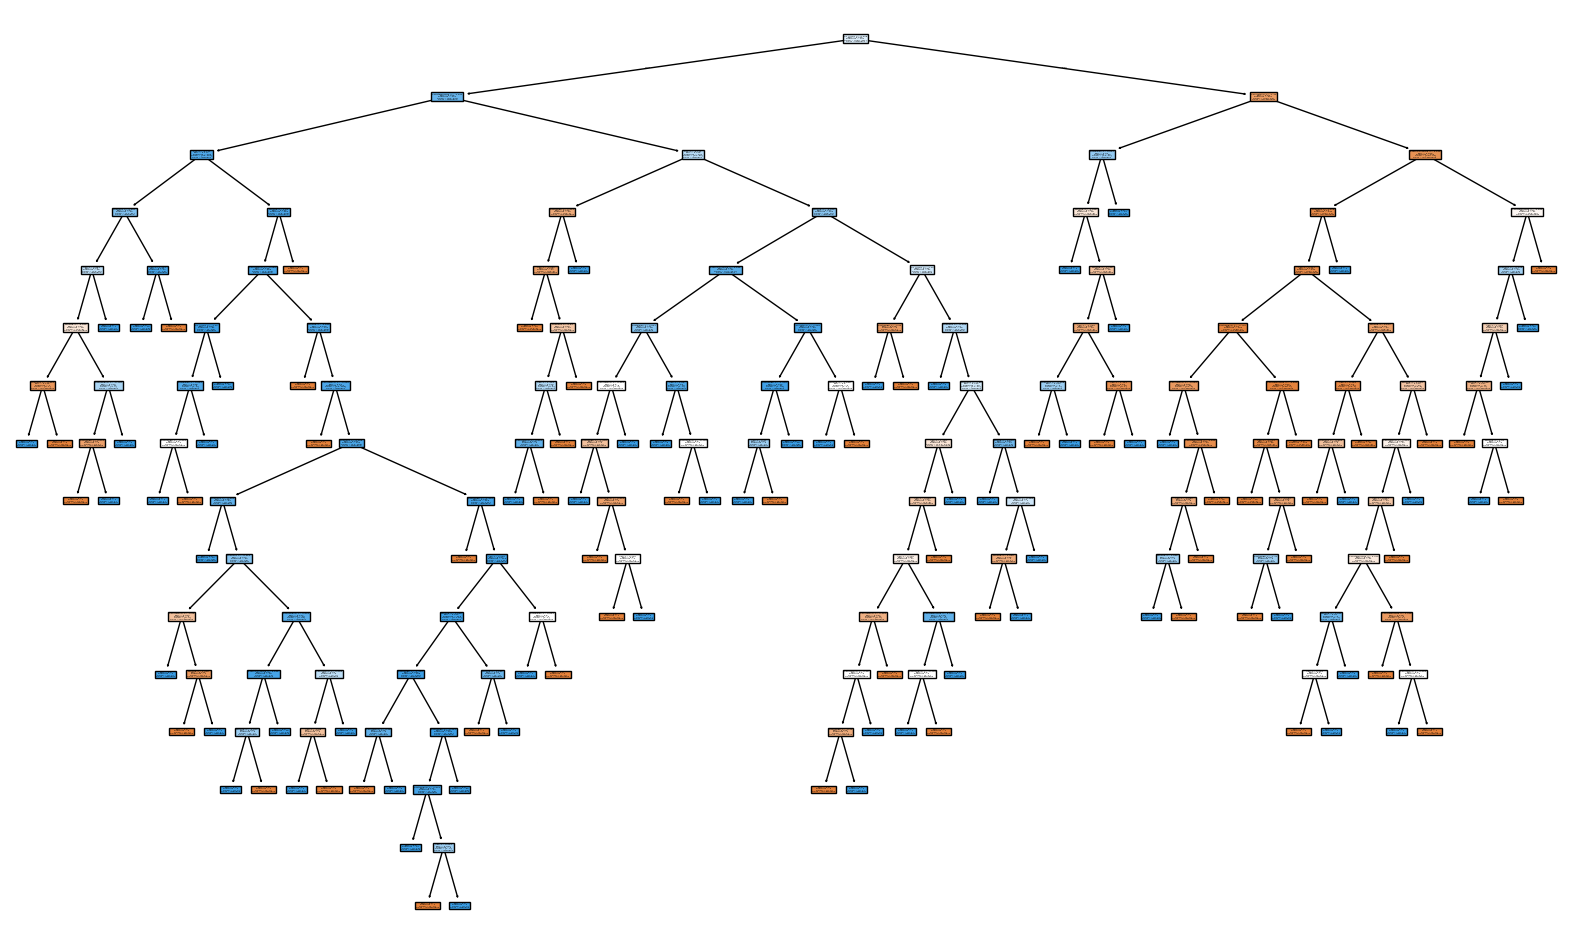

In [72]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))
plot_tree(
    DT,
    filled=True,
    feature_names=df.drop('HeartDisease', axis=1).columns,
    class_names=['No Disease', 'Disease']
);

In [73]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, DT.predict(x_train))
test_acc  = accuracy_score(y_test, DT.predict(x_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 1.0
Test Accuracy : 0.7989130434782609


In [74]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid_dec={
    'max_depth':[10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]

}

grid_search=GridSearchCV(estimator=DT,param_grid=param_grid_dec,cv=5)
grid_search.fit(x_train,y_train)
best_model=grid_search.best_estimator_
y_pred_grid_dec=best_model.predict(x_test)
acc=accuracy_score(y_test,y_pred_grid_dec)
acc

0.8206521739130435

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [76]:
y_pred_rf = rf.predict(x_test)
accuracy = accuracy_score(y_test,y_pred_rf)
conf = confusion_matrix(y_test ,y_pred_rf)
clas =classification_report(y_test,y_pred_rf)

print("accuracyscore_rf",accuracy)
print("Confusionmat_rf",conf)
print("classificationrep_rf",clas)


accuracyscore_rf 0.8804347826086957
Confusionmat_rf [[66 11]
 [11 96]]
classificationrep_rf               precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(rf, param_grid, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)
print("Best Accuracy:", accuracy_score(y_test, grid.best_estimator_.predict(x_test)))

{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy: 0.8858695652173914


In [78]:
# Get feature importance

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=df.drop('HeartDisease', axis=1).columns)
importance = importance.sort_values(ascending=False)

print(importance)

ST_Slope          0.241312
Oldpeak           0.123073
Cholesterol       0.107227
MaxHR             0.103848
ExerciseAngina    0.100046
ChestPainType     0.092671
Age               0.085520
RestingBP         0.066473
Sex               0.033963
RestingECG        0.026302
FastingBS         0.019565
dtype: float64


<Axes: >

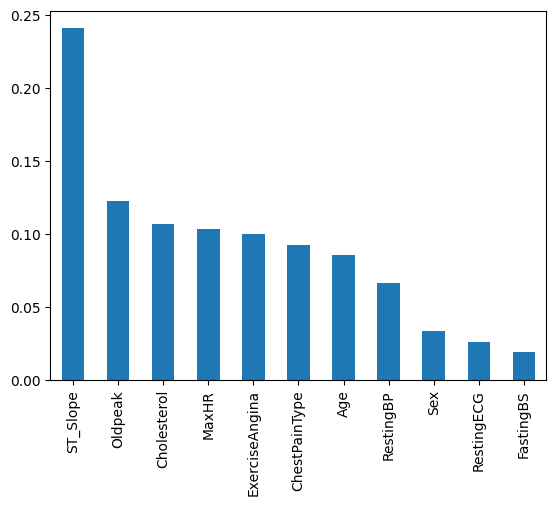

In [79]:
# Visualize feature importance

importance.plot(kind='bar')

Evaluate using cross-validation.

In [83]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
scores = cross_val_score(dt, x, y, cv=5)
print(scores.mean())

0.7362853409360893


In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.86956522 0.83695652 0.82608696 0.81967213 0.75956284]
Mean Accuracy: 0.822368733665954
